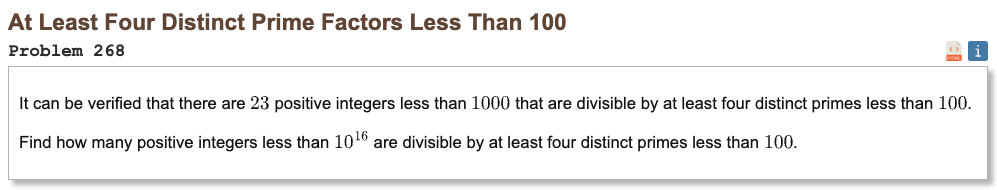

## Initial approach

* list all primes below 100, there are only 25 of them
* any valid number must be divisible by a product made from at least 4 distinct primes in that list
* for one chosen set of primes, the count of multiples is just floor((10^16 - 1) / product)
* a number with 5 or 6 valid prime divisors would be counted too many times, so plain inclusion exclusion is not enough
* use the weighted form of inclusion exclusion where a subset of size k gets weight (-1)^(k-4) × C(k-1, 3)
* this weight makes every number with exactly 4 or more such prime divisors contribute exactly 1 in total
* generate subsets with a depth first search and stop as soon as the running product exceeds the limit
* use math.comb to get the binomial weights easily

In [1]:
from math import comb

def solve():
    limit = 10**16 - 1
    primes = []
    for n in range(2, 100):
        ok = True
        d = 2
        while d * d <= n:
            if n % d == 0:
                ok = False
                break
            d += 1
        if ok:
            primes.append(n)

    result = 0

    def dfs(start, product, used):
        nonlocal result
        for i in range(start, len(primes)):
            p = primes[i]
            if product > limit // p:
                break
            new_product = product * p
            new_used = used + 1
            if new_used >= 4:
                weight = comb(new_used - 1, 3)
                if (new_used - 4) % 2 == 1:
                    weight = -weight
                result += weight * (limit // new_product)
            dfs(i + 1, new_product, new_used)

    dfs(0, 1, 0)
    return result

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 785478606870985
CPU times: user 2.8 s, sys: 4.1 ms, total: 2.81 s
Wall time: 2.81 s
